<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# I.3 Tensão Tangencial Máxima. Círculo de Mohr.

## Problema 7 <a name="PI37"></a>

Considere o estado de tensão na vizinhança do ponto $P$ que se representa na Figura.

[a)](#A) Determine o valor de $\sigma_{yy}$ para o qual a tensão tangencial máxima é mínima e o valor correspondente dessa tensão tangencial máxima.

[b)](#B) Determine as tensões principais para o estado de tensão no ponto $P$.

[c)](#C) Determine as direções principais do estado de tensão em $P$ e escreva a matriz de transformação do referencial $S(O,\vec{\imath},\,\vec{\jmath},\,\vec{k})$ original para o referencial principal $S(O,\vec{e}_\mathrm{I},\vec{e}_\mathrm{II},\vec{e}_\mathrm{III})$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au03/Au03_P007_i1.jpg" width="350" height="150">

## Resolução

#### a) Determine o valor de $\sigma_{yy}$ para o qual a tensão tangencial máxima é mínima e o valor correspondente dessa  tensão tangencial máxima.<a name="A"></a>

([enunciatum](#PI37))

A direção do eixo dos $zz$ é direção principal de tensão. Sendo $\sigma_{zz} = 0$ MPa uma tensão principal de tensão. Neste problema, a tensão tangencial máxima é mínima numa única configuração em que os diferentes círculos de Mohr (nos três planos do referencial ortonormado) são iguais entre si. Esta situação é garantida quando se verifica:

\begin{equation*}
\sigma_\mathrm{II} (\equiv \sigma_\mathrm{III}) = 0
\end{equation*}

Neste caso o círdulo de Mohr para o plano bidimensional $y-z$ é um ponto. É enunciado um estado plano de tensão no plano $x-y$ tal que a matriz das tensões é:

\begin{equation*}
\underline{\underline{\sigma}}^T=
\begin{bmatrix}
\sigma_{xx} & \tau_{yx} \\
\tau_{xy} & \sigma_{yy}
\end{bmatrix} =
\begin{bmatrix}
150 & 80 \\
80 & \sigma_{yy}
\end{bmatrix}~\textrm{(MPa)}
\end{equation*}

Por definiçáo, a tensão de corte máxima (mínima) é:

\begin{equation*}
\tau_\mathrm{max} = \frac{\sigma_\mathrm{I}-\sigma_\mathrm{III}}{2}
= \frac{\sigma_\mathrm{I}}{2}
\end{equation*}

Tensão principal $\sigma_\mathrm{II}$ é determinada pela seguinte equação em função das componentes cartesianas do tensor das tensões:

\begin{equation*}
\sigma_\mathrm{II} = \frac{\sigma_{xx}+\sigma_{yy}}{2} -
\sqrt{\left(\frac{\sigma_{xx}-\sigma_{yy}}{2}\right)^2 + \tau_{xy}^2} = 0~\textrm{MPa}
\quad\Rightarrow\quad\sigma_{yy}
\end{equation*}

e a tensão principal $\sigma_\mathrm{I}$ vem:

\begin{equation*}
\sigma_\mathrm{I} = \frac{\sigma_{xx}+\sigma_{yy}}{2} +
\sqrt{\left(\frac{\sigma_{xx}-\sigma_{yy}}{2}\right)^2 + \tau_{xy}^2} = 2 \tau_\mathrm{max}~\textrm{MPa}
\quad\Rightarrow\quad\tau_\mathrm{max}
\end{equation*}

In [5]:
import sympy as sy
from sympy.solvers import solve
from sympy import symbols

sYY = symbols('sYY')

def tensaoP2(sXX,sYY,sXY):
    return (sXX + sYY)/2 - sy.sqrt((sXX - sYY)**2/4 + sXY**2)
sII = 0

Sxx = 150 # unit: MPa
Sxy = 80

sol = solve([tensaoP2(Sxx,sYY,Sxy) - sII],sYY,dict=True)
resSyy = float(sol[0][sYY])
print('Syy (\leq)','{:.3f}'.format(resSyy),'MPa')

def tensaoP1(sXX,sYY,sXY):
    return (sXX + sYY)/2 + sy.sqrt((sXX - sYY)**2/4 + sXY**2)

sI = tensaoP1(Sxx,resSyy,Sxy)
print('sI = ','{:.3f}'.format(sI),'MPa')

tmax = sI/2
print('tau_max = ','{:.3f}'.format(tmax),'MPa')

Syy (\leq) 42.667 MPa
sI =  192.667 MPa
tau_max =  96.333 MPa


#### b) Determine as tensões principais para o estado de tensão no ponto $P$.<a name="B"></a>

([enunciatum](#PI37))

A matriz de tensões no ponto $P$ é dada por:

\begin{equation*}
\underline{\underline{\sigma}}^T =
\begin{bmatrix}
\sigma_{xx} & \tau_{yx} & \tau_{zx} \\
\tau_{xy} & \sigma_{yy} & \tau_{zy} \\
\tau_{xz} & \tau_{yz} & \sigma_{zz} \\
\end{bmatrix} =
\begin{bmatrix}
150 & 80 & 0 \\
80 & 42.67  & 0 \\
0 & 0 & 0 \\
\end{bmatrix}
\end{equation*}

As tensões principais obtêm-se de:

\begin{equation*}
\det(\sigma_{ji}-\sigma\delta_{ij})= 0
\end{equation*}

In [6]:
import numpy as np
np.set_printoptions(precision=3)

def versor(e1,e2,e3): return np.array([e1,e2,e3])

def sij(sxx,sxy,sxz,syy,syz,szz):
    return np.array([[sxx,sxy,sxz],[sxy,syy,syz],[sxz,syz,szz]])

tt0 = sij(150,80,0,resSyy,0,0)
print('tt0 = \n',tt0)

I1 = np.trace(tt0)
print('\n1º Invariante, I1:', '{:.1f}'.format(I1))

I2 = np.abs(0.5*(np.trace(tt0)**2 -np.trace(np.dot(tt0,tt0))))
print('2º Invariante, I2 :', '{:.1f}'.format(I2))

I3 = np.linalg.det(tt0)
print('3º Invariante, I3 :', '{:.1f}'.format(I3))

print('\n Resolucao Numerica - Numpy : ............................')
valpropriosN = np.around(np.roots([1,-I1,I2,-I3]), decimals=6)
print('\n Numpy : roots = ',valpropriosN)
valpropriosN = np.sort(valpropriosN)
sIII = valpropriosN[0]
sII = valpropriosN[1]
sI = valpropriosN[2]
print('Tensão principal (valor próprio) sI ','{:.2f}'.format(sI))
print('Tensão principal (valor próprio) sII ','{:.2f}'.format(sII))
print('Tensão principal (valor próprio) sIII ','{:.2f}'.format(sIII))

tt0 = 
 [[150.     80.      0.   ]
 [ 80.     42.667   0.   ]
 [  0.      0.      0.   ]]

1º Invariante, I1: 192.7
2º Invariante, I2 : 0.0
3º Invariante, I3 : 0.0

 Resolucao Numerica - Numpy : ............................

 Numpy : roots =  [192.667   0.      0.   ]
Tensão principal (valor próprio) sI  192.67
Tensão principal (valor próprio) sII  0.00
Tensão principal (valor próprio) sIII  0.00


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au03/Au03_P007_i2.jpg"
width="350" height="240">

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au03/Au03_P007_i3.jpg"
width="350" height="250">

#### c) Determine as direções principais do estado de tensão em $P$ e escreva a matriz de transformação do referencial $S(O,\vec{\imath},\,\vec{\jmath},\,\vec{k})$ original para o referencial principal $S(O,\vec{e}_\mathrm{I},\vec{e}_\mathrm{II},\vec{e}_\mathrm{III})$.<a name="C"></a>

([enunciatum](#PI37))

No espaço das tensões da circunferência de Mohr ($\sigma,\tau$) o ângulo entre o referêncial principal e o atual é dado por:

\begin{equation*}
\begin{aligned}
2\theta_{P1} &= \arctan \left(\frac{2\tau_{xy}}{\sigma_{xx}-\sigma_{yy}}\right) \\
2\theta_{P2} &= 2\theta_{P1} + 180^\circ\\
\end{aligned}
\end{equation*}

O ponto $V$ é obtido a partir do ponto $I$ a partir de uma rotação $2\theta$ em torno do ponto $C$. Esta rotação é no sentido do ponteiro dos relógios. Então, na realidade, o vetor de base $\vec{e}_\mathrm{I}$ obtém-se do vetor de base $\vec{e}_1$ por rotação de um ângulo $\theta_P$ e no sentido contrário ao do movimento dos ponteiros do relógio. O vetoer $\vec{e}_\mathrm{II}$ é perpendicular ao vetor de base $\vec{e}_\mathrm{I}$.

A matriz de transformação do referencial $O\vec{\imath}\,\vec{\jmath}\,\vec{k}$ para o referencial principal $O\vec{e}_\mathrm{I}\vec{e}_\mathrm{II}\vec{e}_\mathrm{III}$ vem:

\begin{equation*}
\begin{array}{ccccc}
&& \vec{\imath} & \vec{\jmath} & \vec{k} \\
&& \downarrow & \downarrow & \downarrow \\
\vec{e}_\mathrm{I} & \rightarrow & \vec{e}_1 \cdot \vec{\imath} & \vec{e}_1 \cdot \vec{\jmath} & \vec{e}_1 \cdot \vec{k} \\
\vec{e}_\mathrm{II} & \rightarrow & \vec{e}_2 \cdot \vec{\imath} & \vec{e}_2 \cdot \vec{\jmath} & \vec{e}_2 \cdot \vec{k} \\
\vec{e}_\mathrm{III} & \rightarrow & \vec{e}_3 \cdot \vec{\imath} & \vec{e}_3 \cdot \vec{\jmath} & \vec{e}_3 \cdot \vec{k}
\end{array}
\quad\quad\quad\quad
\begin{aligned}
\text{}\\[2.75ex]
\begin{cases}
\vec{e}_\mathrm{I} &= \cos\theta_\mathrm{P} \vec{\imath} + \sin\theta_\mathrm{P} \vec{\jmath} + 0 \vec{k} \\
\vec{e}_\mathrm{II} &= -\sin\theta_\mathrm{P} \vec{\imath} + \cos\theta_\mathrm{P} \vec{\jmath} + 0 \vec{k} \\
\vec{e}_\mathrm{III} &= 0 \vec{\imath} + 0 \vec{\jmath} + 1 \vec{k} \\
\end{cases}
\end{aligned}
\end{equation*}

em forma matricial,

\begin{equation*}
\begin{bmatrix}
\vec{e}_\mathrm{I} \\ \vec{e}_\mathrm{II} \\ \vec{e}_\mathrm{III}
\end{bmatrix} =
\begin{bmatrix}
\cos\theta_\mathrm{P} & \sin\theta_\mathrm{P} & 0 \\
-\sin\theta_\mathrm{P} & \cos\theta_\mathrm{P} & 0 \\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
\vec{\imath}  \\ \vec{\jmath}  \\ \vec{k}
\end{bmatrix}
\end{equation*}

In [7]:
def angP(s11,s22,s12): return np.arctan((2*s12)/(s11-s22))

sxx = tt0[0,0]
syy = tt0[1,1]
sxy = tt0[0,1]

aP1 = angP(sxx,syy,sxy)
aP2 = aP1 + np.pi

print('angulos das direções principais')
print('\nNo espaço das tensões:')
print('angPI  = ','{:.3f}'.format(np.rad2deg(aP1)),' deg | ','{:.3f}'.format(aP1),' radians')
print('angPII = ','{:.3f}'.format(np.rad2deg(aP2)),' deg | ','{:.3f}'.format(aP2),' radians')

aPI = aP1/2
aPII = aP2/2

print('\nNo espaço fisico:')
print('angPI  =  ','{:.3f}'.format(np.rad2deg(aPI)),' deg | ','{:.3f}'.format(aPI),' radians')
print('angPII = ','{:.3f}'.format(np.rad2deg(aPII)),' deg | ','{:.3f}'.format(aPII),' radians')

def Q(ang,rot):
    c = np.cos(ang)
    s = np.sin(ang)
    if rot == 1:
        Qij = np.array([[1,0,0],[0,c,s],[0,-s,c]])
    elif rot == 2:
        Qij = np.array([[c,0,s],[0,1,0],[-s,0,c]])
    else:
        Qij = np.array([[c,s,0],[-s,c,0],[0,0,1]])
    return Qij

MatrTrans = Q(aPI,3)
print('\nMatriz de transformação = \n',MatrTrans)

print('\nVetores principais:')
nI = MatrTrans[0,:]
print('eI = ', nI)
nII = MatrTrans[1,:]
print('eII = ', nII)
nIII = MatrTrans[2,:]
print('eIII = ', nIII)

angulos das direções principais

No espaço das tensões:
angPI  =  56.145  deg |  0.980  radians
angPII =  236.145  deg |  4.122  radians

No espaço fisico:
angPI  =   28.072  deg |  0.490  radians
angPII =  118.072  deg |  2.061  radians

Matriz de transformação = 
 [[ 0.882  0.471  0.   ]
 [-0.471  0.882  0.   ]
 [ 0.     0.     1.   ]]

Vetores principais:
eI =  [0.882 0.471 0.   ]
eII =  [-0.471  0.882  0.   ]
eIII =  [0. 0. 1.]


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au03/Au03_P007_i4.jpg"
width="350" height="430">

--------------------------
Equações de transformação:
--------------------------

Matriz das tensões tt0 = 
 [[150.     80.      0.   ]
 [ 80.     42.667   0.   ]
 [  0.      0.      0.   ]]

PLANO x-y:

Tensões (normais) principais: -------------------------------------------
angPrincipal 1 (deg) = 28.07
tens xx plano principal [1] (MPa) = 192.67
tens yy plano principal [1] (MPa) = 0.00
tens xy plano principal [1] (MPa) = -0.00
angPrincipal 2 (deg) = 118.07
tens xx plano principal [2] (MPa) = -0.00
tens yy plano principal [2] (MPa) = 192.67
tens xy plano principal [2] (MPa) = 0.00

Tensões de corte maximas/mínima: -------------------------------------------
Ângulo tensão corte max (Deg) = -16.93
tens xx - plano  tensão de corte max (MPa) = 96.33
tens yy - plano  tensão de corte max (MPa) = 96.33
tens xy - plano  tensão de corte max (MPa) = 96.33
Ângulo tensão corte min (Deg) = 73.07
tens xx - plano  tensão de corte min (MPa) = 96.33
tens yy - plano  tensão de corte min (MPa) = 96.33
t

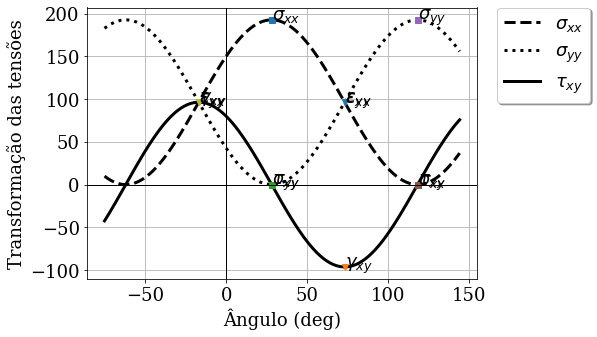

In [8]:
import matplotlib.pyplot as plt
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 18
# rc('text', usetex=True)

print('--------------------------')
print('Equações de transformação:')
print('--------------------------')

print('\nMatriz das tensões tt0 = \n',tt0)

def sxx1(sxx,syy,txy,t):
    return (sxx+syy)/2 + (sxx-syy)/2*np.cos(2*t) + txy*np.sin(2*t)

def syy1(sxx,syy,txy,t):
    return (sxx+syy)/2 - (sxx-syy)/2*np.cos(2*t) - txy*np.sin(2*t)

def txy1(sxx,syy,txy,t):
    return (syy-sxx)/2*np.sin(2*t) + txy*np.cos(2*t)

def angPrincipal(sxx,syy,txy):
    return np.arctan(2*txy/(sxx-syy))/2

def angS(s11,s22,s12): return -np.arctan((s11-s22)/(2*s12))

print('\nPLANO x-y:\n')
sxx = tt0[0,0]
syy = tt0[1,1]
txy = tt0[0,1]

angt = np.arange(-75,145,1)
tsxx = sxx1(sxx,syy,txy,np.deg2rad(angt))
tsyy = syy1(sxx,syy,txy,np.deg2rad(angt))
ttxy = txy1(sxx,syy,txy,np.deg2rad(angt))

print('Tensões (normais) principais: -------------------------------------------')
aprinc = np.rad2deg(angPrincipal(sxx,syy,txy))
print('angPrincipal 1 (deg) =','{:.2f}'.format(aprinc))
tsxx1 = sxx1(sxx,syy,txy,np.deg2rad(aprinc))
tsyy1 = syy1(sxx,syy,txy,np.deg2rad(aprinc))
ttxy1 = txy1(sxx,syy,txy,np.deg2rad(aprinc))
print('tens xx plano principal [1] (MPa) =','{:.2f}'.format(tsxx1))
print('tens yy plano principal [1] (MPa) =','{:.2f}'.format(tsyy1))
print('tens xy plano principal [1] (MPa) =','{:.2f}'.format(ttxy1))

aprinc2 = aprinc + 90
print('angPrincipal 2 (deg) =','{:.2f}'.format(aprinc2))
tsxx2 = sxx1(sxx,syy,txy,np.deg2rad(aprinc2))
tsyy2 = syy1(sxx,syy,txy,np.deg2rad(aprinc2))
ttxy2 = txy1(sxx,syy,txy,np.deg2rad(aprinc2))
print('tens xx plano principal [2] (MPa) =','{:.2f}'.format(tsxx2))
print('tens yy plano principal [2] (MPa) =','{:.2f}'.format(tsyy2))
print('tens xy plano principal [2] (MPa) =','{:.2f}'.format(ttxy2))

print('\nTensões de corte maximas/mínima: -------------------------------------------')
aS1 = angS(sxx,syy,txy)/2 # ângulo no espaço físico, radianos
print('Ângulo tensão corte max (Deg) =','{:.2f}'.format(np.rad2deg(aS1)))
tcortexxMa = sxx1(sxx,syy,txy,aS1)
tcorteyyMa = syy1(sxx,syy,txy,aS1)
tcortexyMa = txy1(sxx,syy,txy,aS1)
print('tens xx - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcortexxMa))
print('tens yy - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcorteyyMa))
print('tens xy - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcortexyMa))

aS2 = aS1 + np.pi/2
print('Ângulo tensão corte min (Deg) =','{:.2f}'.format(np.rad2deg(aS2)))
tcortexxMb = sxx1(sxx,syy,txy,aS2)
tcorteyyMb = syy1(sxx,syy,txy,aS2)
tcortexyMb = txy1(sxx,syy,txy,aS2)
print('tens xx - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcortexxMb))
print('tens yy - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcorteyyMb))
print('tens xy - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcortexyMb))

# use LaTeX fonts in the plot
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(angt, tsxx, 'k--', label=r'$\sigma_{xx}$', linewidth=3)
ax.plot(angt, tsyy, 'k:', label=r'$\sigma_{yy}$', linewidth=3)
ax.plot(angt, ttxy, 'k', label=r'$\tau_{xy}$', linewidth=3)
# points: principal stresses
ax.plot(aprinc, tsxx1, 's'), ax.text(aprinc, tsxx1,r'$\sigma_{xx}$')
ax.plot(aprinc, tsyy1, 's'), ax.text(aprinc, tsyy1,r'$\sigma_{yy}$')
ax.plot(aprinc, ttxy1, 's'), ax.text(aprinc, ttxy1,r'$\tau_{xy}$')
ax.plot(aprinc2, tsxx2, 's'), ax.text(aprinc2, tsxx2,r'$\sigma_{xx}$')
ax.plot(aprinc2, tsyy2, 's'), ax.text(aprinc2, tsyy2,r'$\sigma_{yy}$')
ax.plot(aprinc2, ttxy2, 's'), ax.text(aprinc2, ttxy2,r'$\tau_{xy}$')
# points: critical shear stresses
ax.plot(np.rad2deg(aS1), tcortexxMa, 'v')
ax.text(np.rad2deg(aS1), tcortexxMa,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aS1), tcorteyyMa, 'v')
ax.text(np.rad2deg(aS1), tcorteyyMa,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aS1), tcortexyMa, 'v')
ax.text(np.rad2deg(aS1), tcortexyMa,r'$\gamma_{xy}$')
ax.plot(np.rad2deg(aS2), tcortexxMb, 'v')
ax.text(np.rad2deg(aS2), tcortexxMb,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aS2), tcorteyyMb, 'v')
ax.text(np.rad2deg(aS2), tcorteyyMb,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aS2), tcortexyMb, 'v')
ax.text(np.rad2deg(aS2), tcortexyMb,r'$\gamma_{xy}$')

ax.set(xlabel='Ângulo (deg)', ylabel='Transformação das tensões')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., shadow=True, fontsize=18)
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>